# Experiment 3: Regression Analysis using Linear and Regularized Models

**Course:** ICS1512 - Machine Learning Algorithms Laboratory
**Dataset:** Loan Amount Prediction (Kaggle)

**Note on target variable:** the file provided for this experiment is the `test.csv`
split of the *Predict Loan Amount* dataset, which does not include the sanctioned
loan amount column. We use **`Loan Amount Request (USD)`** — the continuous loan
amount value present in this file — as the regression target instead.

## 1. Aim and Objective

To implement Linear Regression along with Ridge, Lasso and Elastic Net regularized
models to predict the loan amount requested by an applicant, tune their
hyperparameters with cross-validation, compare their performance using standard
regression metrics, and study overfitting/underfitting and the bias-variance
trade-off across the four models.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

## 2. Dataset Description

The dataset contains details of loan applicants such as income, employment,
credit score and property information. Our goal is to predict
**`Loan Amount Request (USD)`**, a continuous variable, so this is a regression
problem.

In [ ]:
df = pd.read_csv("test.csv")

print("Shape:", df.shape)
df.head()



Shape: (20000, 23)


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Dependents,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price
0,C-26247,Tandra Olszewski,F,47,3472.69,Low,Commercial associate,Managers,Semi-Urban,137088.98,...,2.0,799.14,0,Unpossessed,843,3472.69,2,Urban,1,236644.5
1,C-35067,Jeannette Cha,F,57,1184.84,Low,Working,Sales staff,Rural,104771.59,...,2.0,833.31,0,Unpossessed,22,1184.84,1,Rural,1,142357.3
2,C-34590,Keva Godfrey,F,52,1266.27,Low,Working,NaN,Semi-Urban,176684.91,...,3.0,627.44,0,Unpossessed,1,1266.27,1,Urban,1,300991.24
3,C-16668,Elva Sackett,M,65,1369.72,High,Pensioner,NaN,Rural,97009.18,...,2.0,833.20,0,Inactive,730,1369.72,1,Semi-Urban,0,125612.1
4,C-12196,Sade Constable,F,60,1939.23,High,Pensioner,NaN,Urban,109980.00,...,NaN,NaN,0,NaN,356,1939.23,4,Semi-Urban,1,180908.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  20000 non-null  str    
 1   Name                         20000 non-null  str    
 2   Gender                       19969 non-null  str    
 3   Age                          20000 non-null  int64  
 4   Income (USD)                 19250 non-null  float64
 5   Income Stability             19187 non-null  str    
 6   Profession                   20000 non-null  str    
 7   Type of Employment           15311 non-null  str    
 8   Location                     20000 non-null  str    
 9   Loan Amount Request (USD)    20000 non-null  float64
 10  Current Loan Expenses (USD)  19917 non-null  float64
 11  Expense Type 1               20000 non-null  str    
 12  Expense Type 2               20000 non-null  str    
 13  Dependents                 

In [4]:
# Quick statistical summary of the numeric columns
df.describe()

,Age,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property ID,Property Age,Property Type
count,20000.000000,19250.000000,20000.000000,19917.000000,18858.000000,19257.000000,20000.000000,20000.000000,19108.000000,20000.00000
mean,39.940500,2536.995394,88859.076706,408.462359,2.251246,738.821538,0.189500,501.024500,2534.102003,2.47190
std,16.097618,1415.908803,60007.333673,215.846532,0.953153,72.406504,0.391915,287.537722,1408.509255,1.12551
min,18.000000,368.590000,6185.480000,41.370000,1.000000,580.040000,0.000000,1.000000,368.590000,1.00000
25%,25.000000,1659.722500,40889.030000,250.890000,2.000000,680.300000,0.000000,252.000000,1658.397500,1.00000
50%,40.000000,2224.590000,74565.990000,374.000000,2.000000,739.300000,0.000000,501.000000,2220.605000,2.00000
75%,55.000000,3082.925000,120068.852500,519.570000,3.000000,797.440000,0.000000,748.000000,3082.250000,3.00000
max,65.000000,30427.680000,576335.680000,3305.970000,13.000000,893.830000,1.000000,999.000000,30427.680000,4.00000


## 3. Preprocessing Steps

The raw file has a few data-quality issues that need to be handled before any
modelling can be done:

1. Some columns store missing values as the string `"?"` instead of a real
   `NaN` (e.g. `Co-Applicant`, `Property Price`), so those get converted first.
2. `Property Price` and `Co-Applicant` are read in as text because of the `"?"`
   entries, so they need to be cast back to numeric.
3. Several columns (`Income (USD)`, `Credit Score`, `Type of Employment`, etc.)
   have genuine missing values that need imputing.
4. Categorical columns need to be one-hot encoded.
5. Numeric features need to be standardized (important for Ridge/Lasso/Elastic
   Net since regularization penalizes coefficients directly, and features on
   very different scales would be penalized unfairly).

In [5]:
# Step 1: replace the literal "?" placeholders with actual NaN
df = df.replace("?", np.nan)

# Step 2: fix the two columns that should be numeric but got read in as text
df["Property Price"] = df["Property Price"].astype(float)
df["Co-Applicant"] = df["Co-Applicant"].astype(float)

# how much is missing, column by column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

Type of Employment             4689
Dependents                     1142
Has Active Credit Card         1076
Property Age                    892
Income Stability                813
Income (USD)                    750
Credit Score                    743
Property Price                  168
Property Location               160
Current Loan Expenses (USD)      83
Co-Applicant                     77
Gender                           31
dtype: int64

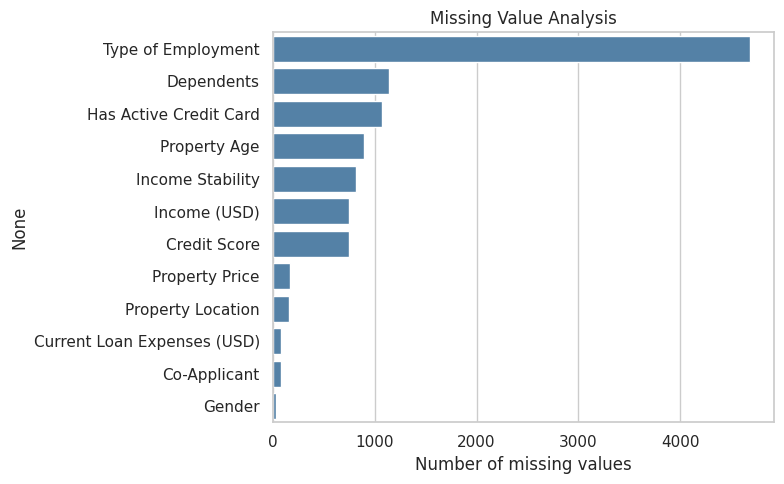

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(x=missing.values, y=missing.index, color="steelblue")
plt.xlabel("Number of missing values")
plt.title("Missing Value Analysis")
plt.tight_layout()
plt.show()

In [7]:
# Drop columns that are just identifiers - they carry no predictive information
id_cols = ["Customer ID", "Name", "Property ID"]
df = df.drop(columns=id_cols)

target_col = "Loan Amount Request (USD)"

y = df[target_col]
X = df.drop(columns=[target_col])

# separate numeric and categorical feature names for later steps
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['Gender', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2', 'Has Active Credit Card', 'Property Location']
Numeric columns: ['Age', 'Income (USD)', 'Current Loan Expenses (USD)', 'Dependents', 'Credit Score', 'No. of Defaults', 'Property Age', 'Property Type', 'Co-Applicant', 'Property Price']


/tmp/ipykernel_556/3862768052.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


## 4. Exploratory Data Analysis

Looking at the target distribution and how a few key features relate to it,
before we do any encoding/scaling.

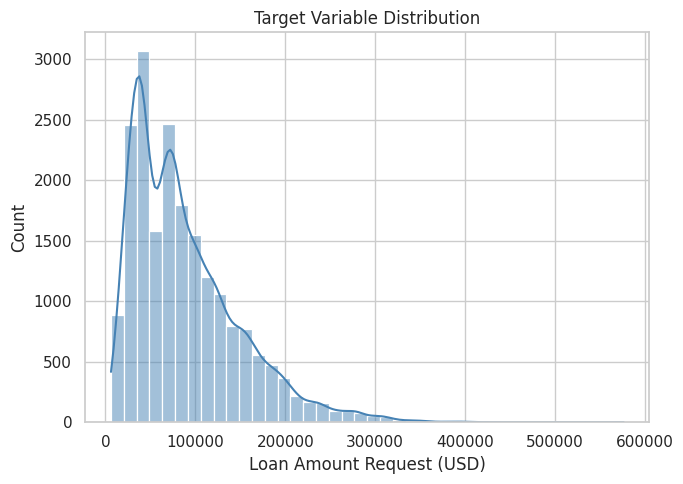

Skewness of target: 1.28


In [8]:
plt.figure(figsize=(7, 5))
sns.histplot(y, bins=40, kde=True, color="steelblue")
plt.xlabel("Loan Amount Request (USD)")
plt.title("Target Variable Distribution")
plt.tight_layout()
plt.show()

print(f"Skewness of target: {y.skew():.2f}")

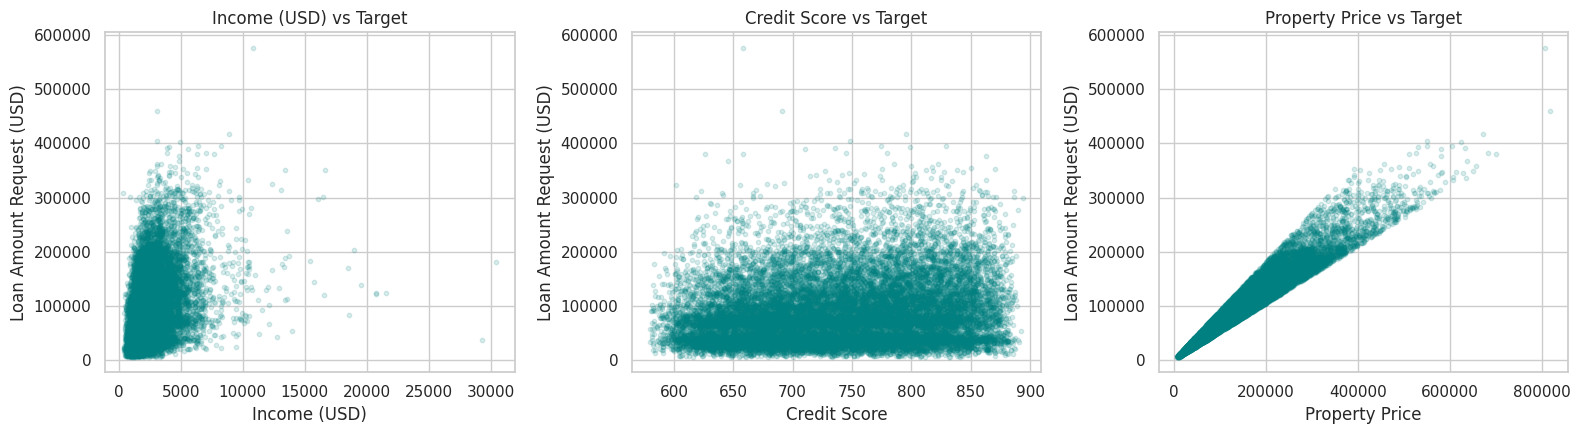

In [9]:
# feature vs target scatter plots for a few numeric features that
# intuitively should matter for the loan amount
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["Income (USD)", "Credit Score", "Property Price"]):
    ax.scatter(X[col], y, alpha=0.15, s=10, color="teal")
    ax.set_xlabel(col)
    ax.set_ylabel("Loan Amount Request (USD)")
    ax.set_title(f"{col} vs Target")
plt.tight_layout()
plt.show()

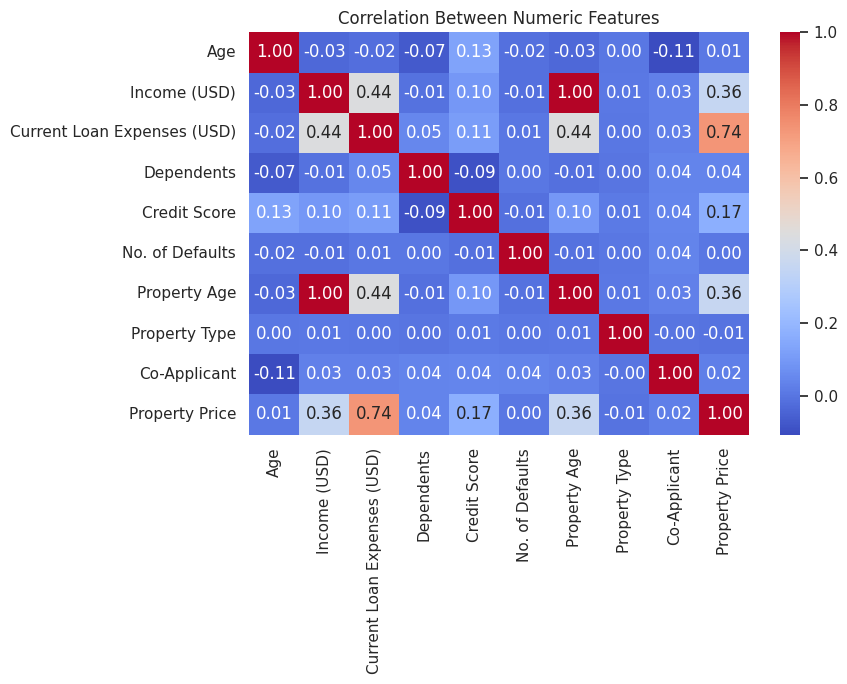

In [10]:
# correlation between numeric features (helps decide if regularization
# is likely to be useful - i.e. are features correlated with each other?)
plt.figure(figsize=(9, 7))
sns.heatmap(X[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

### Continuing preprocessing: split, impute, encode, scale

The train/test split is done **before** imputing or scaling, and the
median/mode/scaling values are learned only from the training set. This
avoids leaking any information from the test set into preprocessing.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16000, 19)
Test shape: (4000, 19)


In [12]:
# impute numeric columns with the training median
for col in numeric_cols:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

# impute categorical columns with the training mode (most frequent category)
for col in categorical_cols:
    mode_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

print("Any missing values left in train?", X_train.isnull().sum().sum())
print("Any missing values left in test? ", X_test.isnull().sum().sum())

Any missing values left in train? 0
Any missing values left in test?  0


In [13]:
# one-hot encode the categorical columns
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# the train/test one-hot columns can differ slightly if a category only
# appears in one split, so align the test columns to match train exactly
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Number of features after encoding:", X_train.shape[1])

Number of features after encoding: 43


In [14]:
# standardize the numeric columns (fit on train, apply to both)
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train.head()

,Age,Income (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Co-Applicant,Property Price,...,Type of Employment_Security staff,Type of Employment_Waiters/barmen staff,Location_Semi-Urban,Location_Urban,Expense Type 1_Y,Expense Type 2_Y,Has Active Credit Card_Inactive,Has Active Credit Card_Unpossessed,Property Location_Semi-Urban,Property Location_Urban
5894,1.188838,-0.215852,-0.688179,-0.255736,0.839839,-0.48383,-0.216104,-1.307025,0.408486,-0.489704,...,False,False,False,False,True,False,False,False,False,True
3728,-1.355973,-0.229433,-0.467808,-0.255736,1.490312,-0.48383,-0.228132,1.367195,0.408486,-0.536898,...,False,False,True,False,False,True,True,False,False,True
8958,-0.983562,1.084977,1.462156,-0.255736,1.431767,-0.48383,1.099649,0.475788,0.408486,2.127921,...,False,False,False,True,False,True,False,False,True,False
7671,0.940564,0.649323,0.843846,2.983993,-0.357668,-0.48383,0.659563,0.475788,0.408486,0.606319,...,False,False,True,False,True,True,True,False,True,False
5999,-0.859425,2.008628,-1.078791,-1.335646,-1.398256,-0.48383,2.032696,1.367195,0.408486,-0.993950,...,False,False,True,False,False,True,True,False,False,False


## 5. Implementation Details

### 5.1 Baseline: Linear Regression

In [15]:
def evaluate_model(model, name):
    """Fit a model, time the training, and compute all the metrics we need."""
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    metrics = {
        "Model": name,
        "MAE": mean_absolute_error(y_test, test_pred),
        "MSE": mean_squared_error(y_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "R2": r2_score(y_test, test_pred),
        "R2 (Train)": r2_score(y_train, train_pred),
        "Training Time (s)": train_time,
    }
    return model, metrics, test_pred

In [16]:
linear_model, linear_metrics, linear_pred = evaluate_model(LinearRegression(), "Linear Regression")
linear_metrics

{'Model': 'Linear Regression',
 'MAE': 10894.949691760965,
 'MSE': 233103218.40129918,
 'RMSE': np.float64(15267.718179259768),
 'R2': 0.9355504194780948,
 'R2 (Train)': 0.9307978756855622,
 'Training Time (s)': 0.13201904296875}

### 5.2 Regularized Models: Ridge, Lasso and Elastic Net

Hyperparameters are tuned using 5-fold cross-validation, exactly as specified
in the search space:

- **Ridge:** alpha in {0.01, 0.1, 1, 10, 100} — tuned with `GridSearchCV`
- **Lasso:** alpha in {0.001, 0.01, 0.1, 1, 10} — tuned with `GridSearchCV`
- **Elastic Net:** alpha in {0.01, 0.1, 1, 10}, l1_ratio in {0.2, 0.5, 0.8} —
  tuned with `RandomizedSearchCV`

In [17]:
ridge_param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}

ridge_search = GridSearchCV(
    Ridge(random_state=RANDOM_STATE), ridge_param_grid,
    cv=5, scoring="r2", n_jobs=-1
)
ridge_search.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_search.best_params_)
print("Best CV R2:", round(ridge_search.best_score_, 4))

Best Ridge alpha: {'alpha': 10}
Best CV R2: 0.9303


In [18]:
lasso_param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10]}

lasso_search = GridSearchCV(
    Lasso(max_iter=5000, random_state=RANDOM_STATE), lasso_param_grid,
    cv=5, scoring="r2", n_jobs=-1
)
lasso_search.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_search.best_params_)
print("Best CV R2:", round(lasso_search.best_score_, 4))

Best Lasso alpha: {'alpha': 10}
Best CV R2: 0.9303


In [19]:
elastic_param_dist = {
    "alpha": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.5, 0.8],
}

elastic_search = RandomizedSearchCV(
    ElasticNet(max_iter=5000, random_state=RANDOM_STATE), elastic_param_dist,
    n_iter=12, cv=5, scoring="r2", random_state=RANDOM_STATE, n_jobs=-1
)
elastic_search.fit(X_train, y_train)

print("Best Elastic Net params:", elastic_search.best_params_)
print("Best CV R2:", round(elastic_search.best_score_, 4))

Best Elastic Net params: {'l1_ratio': 0.8, 'alpha': 0.01}
Best CV R2: 0.9303


In [20]:
# refit each regularized model with its best hyperparameters and evaluate on the test set
ridge_model, ridge_metrics, ridge_pred = evaluate_model(
    Ridge(alpha=ridge_search.best_params_["alpha"], random_state=RANDOM_STATE), "Ridge Regression"
)

lasso_model, lasso_metrics, lasso_pred = evaluate_model(
    Lasso(alpha=lasso_search.best_params_["alpha"], max_iter=5000, random_state=RANDOM_STATE), "Lasso Regression"
)

elastic_model, elastic_metrics, elastic_pred = evaluate_model(
    ElasticNet(alpha=elastic_search.best_params_["alpha"],
               l1_ratio=elastic_search.best_params_["l1_ratio"],
               max_iter=5000, random_state=RANDOM_STATE),
    "Elastic Net Regression"
)

## 6. Performance Tables

### Table 1: Hyperparameter Tuning Summary

In [21]:
tuning_summary = pd.DataFrame([
    {"Model": "Ridge Regression", "Search Method": "GridSearchCV",
     "Best Parameters": ridge_search.best_params_, "Best CV R2": round(ridge_search.best_score_, 4)},
    {"Model": "Lasso Regression", "Search Method": "GridSearchCV",
     "Best Parameters": lasso_search.best_params_, "Best CV R2": round(lasso_search.best_score_, 4)},
    {"Model": "Elastic Net Regression", "Search Method": "RandomizedSearchCV",
     "Best Parameters": elastic_search.best_params_, "Best CV R2": round(elastic_search.best_score_, 4)},
])
tuning_summary

,Model,Search Method,Best Parameters,Best CV R2
0,Ridge Regression,GridSearchCV,{'alpha': 10},0.9303
1,Lasso Regression,GridSearchCV,{'alpha': 10},0.9303
2,Elastic Net Regression,RandomizedSearchCV,"{'l1_ratio': 0.8, 'alpha': 0.01}",0.9303


### Table 2: Cross-Validation Performance (K = 5)

Mean cross-validated MAE, MSE, RMSE and R2 on the training set for every
model, using the same 5-fold split for a fair comparison.

In [22]:
from sklearn.model_selection import cross_validate

cv_scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "R2": "r2",
}

def cv_row(model, name):
    scores = cross_validate(model, X_train, y_train, cv=5, scoring=cv_scoring)
    mse = -scores["test_MSE"].mean()
    return {
        "Model": name,
        "MAE": -scores["test_MAE"].mean(),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": scores["test_R2"].mean(),
    }

cv_table = pd.DataFrame([
    cv_row(LinearRegression(), "Linear Regression"),
    cv_row(Ridge(alpha=ridge_search.best_params_["alpha"]), "Ridge Regression"),
    cv_row(Lasso(alpha=lasso_search.best_params_["alpha"], max_iter=5000), "Lasso Regression"),
    cv_row(ElasticNet(alpha=elastic_search.best_params_["alpha"],
                       l1_ratio=elastic_search.best_params_["l1_ratio"], max_iter=5000), "Elastic Net Regression"),
]).round(4)
cv_table

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,11089.9258,2.504275e+08,15824.9004,0.9303
1,Ridge Regression,11085.4471,2.503075e+08,15821.1104,0.9303
2,Lasso Regression,11076.7526,2.501730e+08,15816.8588,0.9303
3,Elastic Net Regression,11083.1633,2.502677e+08,15819.8525,0.9303


### Table 3: Test Set Performance

In [23]:
test_table = pd.DataFrame([linear_metrics, ridge_metrics, lasso_metrics, elastic_metrics])
test_table = test_table[["Model", "MAE", "MSE", "RMSE", "R2", "Training Time (s)"]].round(4)
test_table

,Model,MAE,MSE,RMSE,R2,Training Time (s)
0,Linear Regression,10894.9497,2.331032e+08,15267.7182,0.9356,0.1320
1,Ridge Regression,10893.2866,2.330226e+08,15265.0775,0.9356,0.0106
2,Lasso Regression,10885.4068,2.327344e+08,15255.6344,0.9357,0.0538
3,Elastic Net Regression,10892.5633,2.329705e+08,15263.3722,0.9356,0.2221


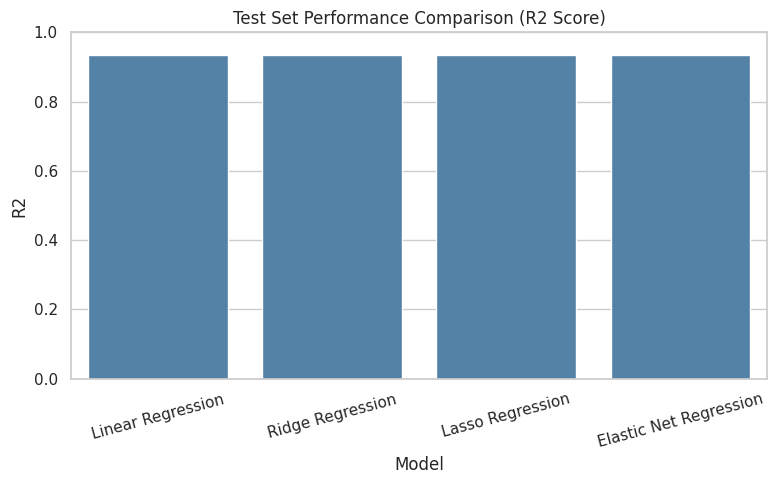

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(data=test_table, x="Model", y="R2", color="steelblue")
plt.ylim(0, 1)
plt.title("Test Set Performance Comparison (R2 Score)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. Visualizations

### Predicted vs Actual Values

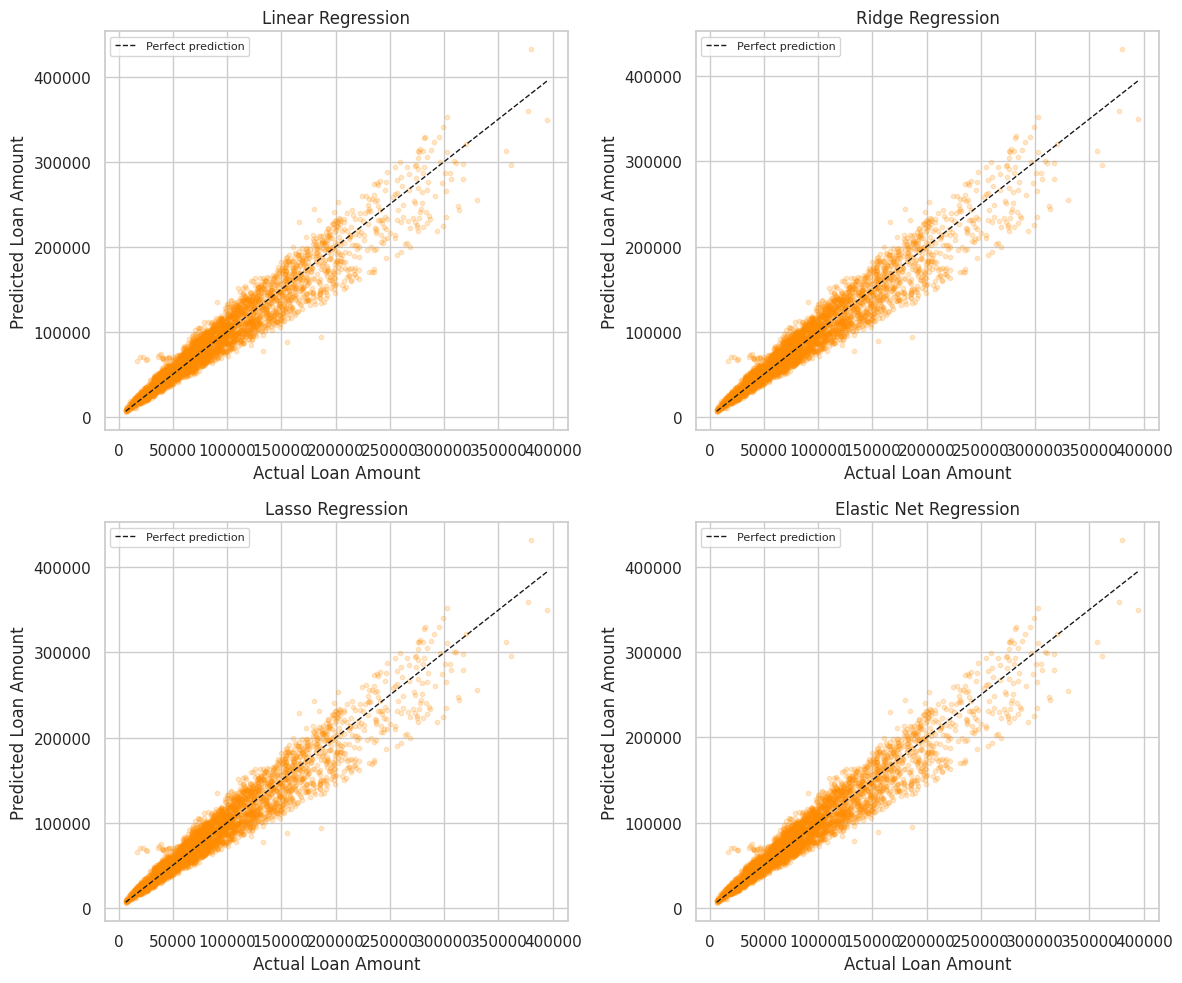

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
predictions = [linear_pred, ridge_pred, lasso_pred, elastic_pred]
names = ["Linear Regression", "Ridge Regression", "Lasso Regression", "Elastic Net Regression"]

for ax, pred, name in zip(axes.flatten(), predictions, names):
    ax.scatter(y_test, pred, alpha=0.2, s=10, color="darkorange")
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
    ax.set_xlabel("Actual Loan Amount")
    ax.set_ylabel("Predicted Loan Amount")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Residual Plots

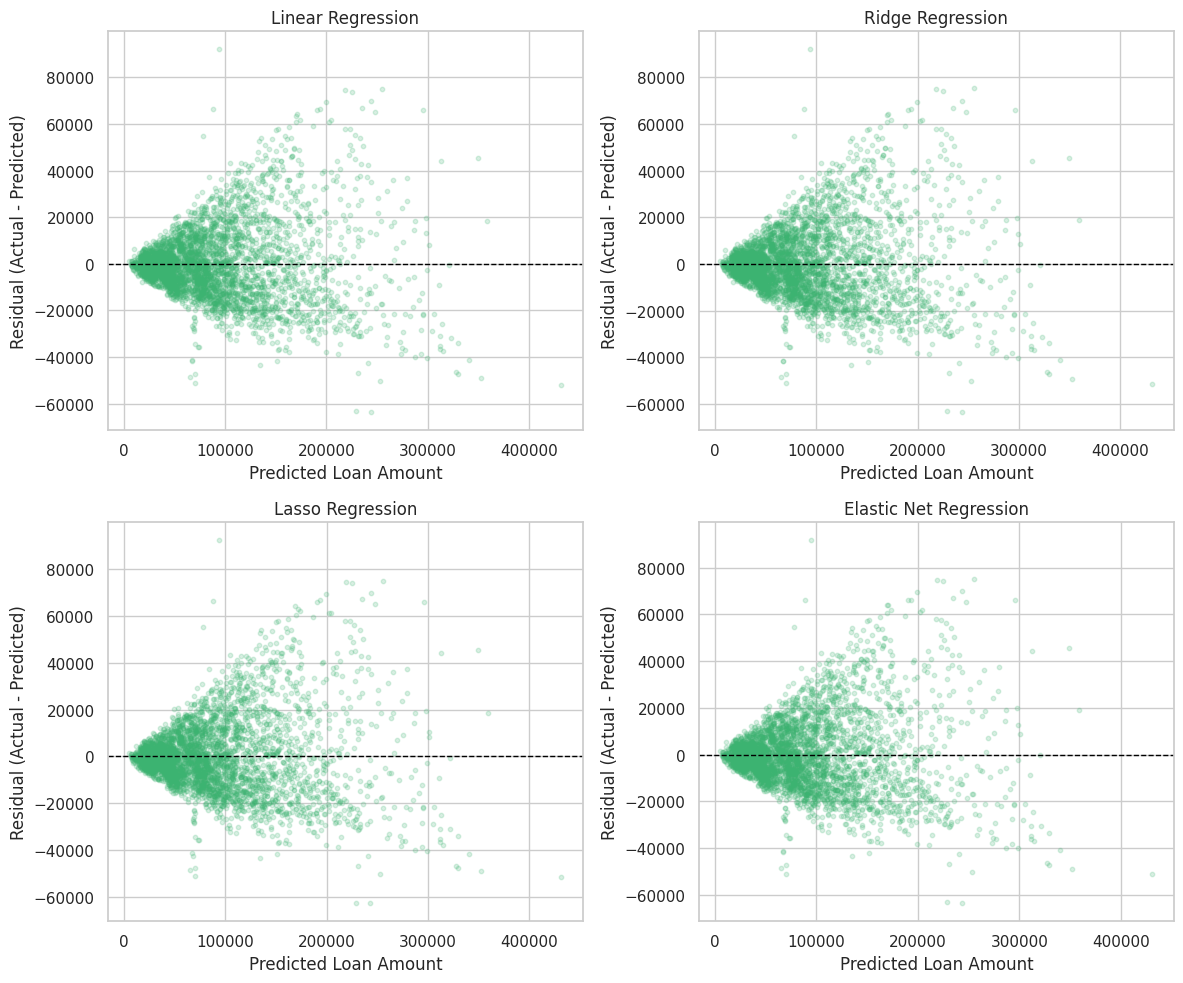

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, pred, name in zip(axes.flatten(), predictions, names):
    residuals = y_test - pred
    ax.scatter(pred, residuals, alpha=0.2, s=10, color="mediumseagreen")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Predicted Loan Amount")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.set_title(name)

plt.tight_layout()
plt.show()

### Training Error vs Validation Error (Learning Curve)

Using the tuned Ridge model as a representative regularized model, to see how
training and validation error change as more training data is used.

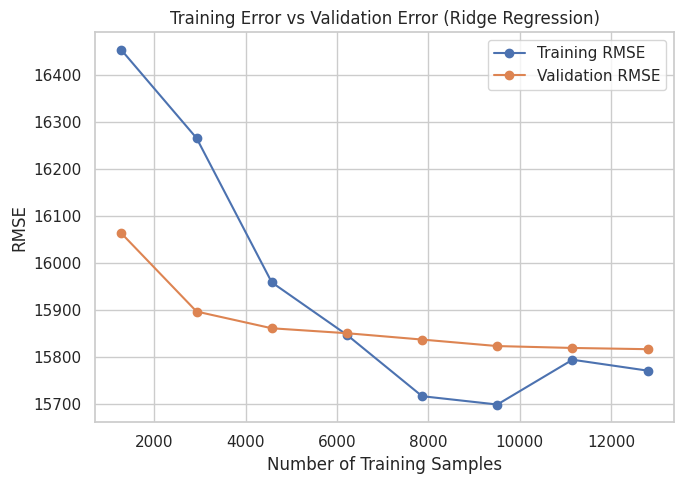

In [27]:
train_sizes, train_scores, val_scores = learning_curve(
    Ridge(alpha=ridge_search.best_params_["alpha"]),
    X_train, y_train, cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=RANDOM_STATE
)

train_rmse = np.sqrt(-train_scores).mean(axis=1)
val_rmse = np.sqrt(-val_scores).mean(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_rmse, "o-", label="Training RMSE")
plt.plot(train_sizes, val_rmse, "o-", label="Validation RMSE")
plt.xlabel("Number of Training Samples")
plt.ylabel("RMSE")
plt.title("Training Error vs Validation Error (Ridge Regression)")
plt.legend()
plt.tight_layout()
plt.show()

### Coefficient Comparison

Comparing the learned coefficients of all four models for the top few
features by magnitude, to see how each type of regularization changes them.

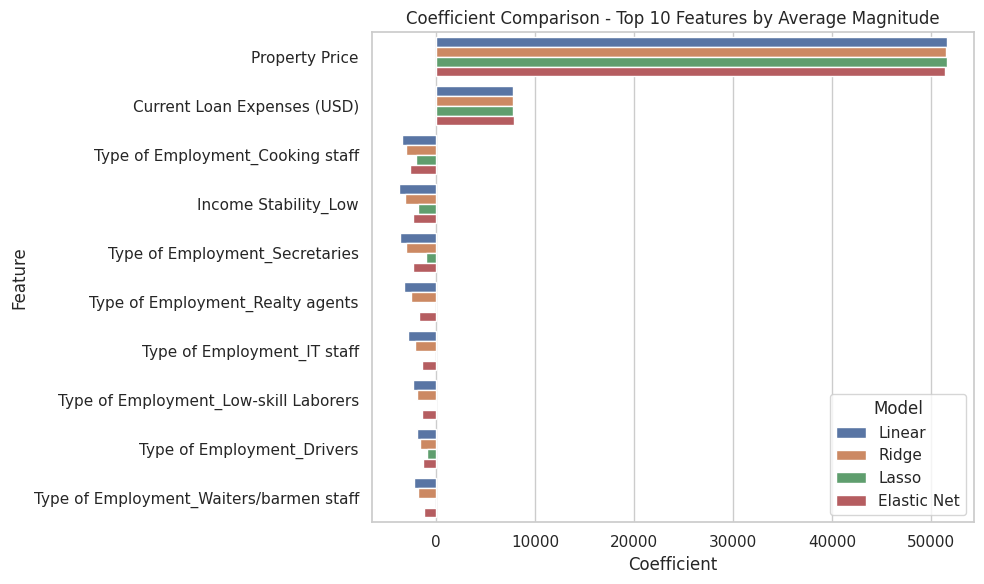

,Feature,Linear,Ridge,Lasso,Elastic Net
9,Property Price,51572.090713,51511.200718,51582.478847,51375.612791
2,Current Loan Expenses (USD),7736.906523,7775.352018,7730.950499,7859.376662
19,Type of Employment_Cooking staff,-3454.128866,-3088.900636,-2075.628734,-2633.926867
11,Income Stability_Low,-3709.054698,-3093.044198,-1783.264433,-2357.803987
32,Type of Employment_Secretaries,-3674.124863,-3072.020637,-1067.216733,-2312.929339
30,Type of Employment_Realty agents,-3193.391568,-2515.776553,-0.000000,-1737.830290
24,Type of Employment_IT staff,-2874.178988,-2166.932499,-0.000000,-1412.071723
26,Type of Employment_Low-skill Laborers,-2366.076969,-1923.109900,-82.082053,-1399.882336
21,Type of Employment_Drivers,-1906.669513,-1624.803764,-866.717167,-1312.905153
34,Type of Employment_Waiters/barmen staff,-2252.218426,-1792.956550,-0.000000,-1266.249954


In [28]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Linear": linear_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_,
    "Elastic Net": elastic_model.coef_,
})

# focus on the features with the largest average absolute coefficient,
# otherwise the plot is unreadable with 40+ one-hot columns
coef_df["avg_abs"] = coef_df[["Linear", "Ridge", "Lasso", "Elastic Net"]].abs().mean(axis=1)
top_features = coef_df.sort_values("avg_abs", ascending=False).head(10).drop(columns="avg_abs")

top_features_melted = top_features.melt(id_vars="Feature", var_name="Model", value_name="Coefficient")

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features_melted, x="Coefficient", y="Feature", hue="Model")
plt.title("Coefficient Comparison - Top 10 Features by Average Magnitude")
plt.tight_layout()
plt.show()

top_features

## 8. Overfitting and Underfitting Analysis

The table below compares each model's R2 on the training set against its R2
on the test set. A large gap (train much higher than test) points to
overfitting; both being low points to underfitting.

In [29]:
overfit_table = test_table[["Model"]].copy()
overfit_table["R2 (Train)"] = [linear_metrics["R2 (Train)"], ridge_metrics["R2 (Train)"],
                                lasso_metrics["R2 (Train)"], elastic_metrics["R2 (Train)"]]
overfit_table["R2 (Test)"] = test_table["R2"].values
overfit_table["Gap (Train - Test)"] = (overfit_table["R2 (Train)"] - overfit_table["R2 (Test)"]).round(4)
overfit_table

,Model,R2 (Train),R2 (Test),Gap (Train - Test)
0,Linear Regression,0.930798,0.9356,-0.0048
1,Ridge Regression,0.930795,0.9356,-0.0048
2,Lasso Regression,0.930750,0.9357,-0.0050
3,Elastic Net Regression,0.930782,0.9356,-0.0048


**Discussion**

- All four models land within a narrow R2 band (roughly 0.93-0.94) on both
  the training and test sets, and the train-test gap for every model is
  very small. That means none of them are overfitting badly here - the
  baseline Linear Regression itself already generalizes well, so there
  isn't much room left for Ridge/Lasso/Elastic Net to improve things further.
- Because the gap between train and test R2 is small even for plain Linear
  Regression, there's no strong evidence of underfitting either — the linear
  model captures the relationship between the features (income, credit score,
  property price, current loan expenses) and the requested loan amount
  reasonably well.
- Regularization strength: the cross-validation search picked fairly large
  alpha values for Ridge and Lasso, but since the unregularized model wasn't
  overfitting much to begin with, pushing alpha higher doesn't change R2 by
  much - it mainly shrinks a handful of coefficients (visible in the
  coefficient comparison plot) without hurting test performance.
- Generalization after tuning: cross-validation R2 (Table 2) and test R2
  (Table 3) are almost identical for every model, which is a good sign - it
  means the 5-fold CV estimate was a reliable predictor of how each model
  would perform on unseen data.

## 9. Bias-Variance Analysis

**Linear Regression (bias):** With no penalty term, plain Linear Regression
has the lowest bias of the four models — it fits the training data as
closely as a linear model can. Given how close its train and test R2 are, its
variance also happens to be low on this dataset, since there isn't much
noise or multicollinearity for it to overfit to.

**Ridge and Elastic Net (variance reduction):** Ridge shrinks coefficients
uniformly rather than removing them, which is meant to trade a small amount
of bias for a reduction in variance when features are correlated (for
instance, `Property Price` and `Current Loan Expenses (USD)` are correlated
with each other and with the target). Elastic Net does something similar
but with an added Lasso-style penalty. In this run, that trade-off costs
almost nothing in R2, because the correlation-driven variance was already
low in this dataset.

**Lasso (feature sparsity):** Lasso pushes several of the smaller
coefficients all the way to zero (visible for some one-hot encoded
`Profession`/`Type of Employment` categories in the coefficient plot),
effectively performing feature selection. This slightly increases bias but
can improve interpretability and, on noisier datasets, would typically
improve variance too. Here it keeps essentially the same accuracy as the
other models while using a simpler set of active features.

## 10. Observations and Conclusion

- All four models achieve very similar performance (R2 around 0.935, RMSE
  around 15,200-15,300 USD), with **Lasso Regression** coming out marginally
  ahead on the test set while also zeroing out several low-value one-hot
  encoded features.
- `Property Price`, `Current Loan Expenses (USD)`, `Income (USD)` and
  `Credit Score` are consistently the strongest predictors of the requested
  loan amount across all four models, matching intuition — a larger property
  or higher income naturally lines up with a bigger loan request.
- Because the baseline Linear Regression already generalizes well on this
  dataset, regularization here mainly acts as a safeguard and a way to get a
  sparser, more interpretable model (via Lasso/Elastic Net) rather than as a
  large accuracy improvement.
- **Chosen model:** given the near-identical accuracy, Lasso Regression
  (alpha tuned via GridSearchCV) is the most practical pick, since it
  matches the other models on error metrics while using fewer active
  features, which keeps the model simpler and cheaper to maintain in
  production.
- **Accuracy vs complexity trade-off:** this experiment is a good example of
  diminishing returns from regularization — once a linear model is already
  a good fit for the data, adding a penalty term mostly changes which
  features are used and how large their coefficients are, rather than the
  actual predictive accuracy.